In [1]:
import laspy
import pandas as pd
import numpy as np
import nbimporter
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys

from read_plot_voxelization import export_filtered_las, show_voxelgrid_plotly, point_cloud_to_dataframe, print_edges, plot_point_cloud_points

las_path = "./synthetic_row_overlap.las"
df = point_cloud_to_dataframe(las_path, True)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
📂 Loading LAS/LAZ file: ./synthetic_row_overlap.las
Number of points: 160,093
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue']
Applied LAS header scale+offset to X,Y,Z.
DataFrame created. Shape: (160093, 19)


In [2]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys
import sys
print(sys.executable)


/home/luka/Coding/DIPLOMSKI-RAD/venv/bin/python


Point cloud details: (160093, 3)


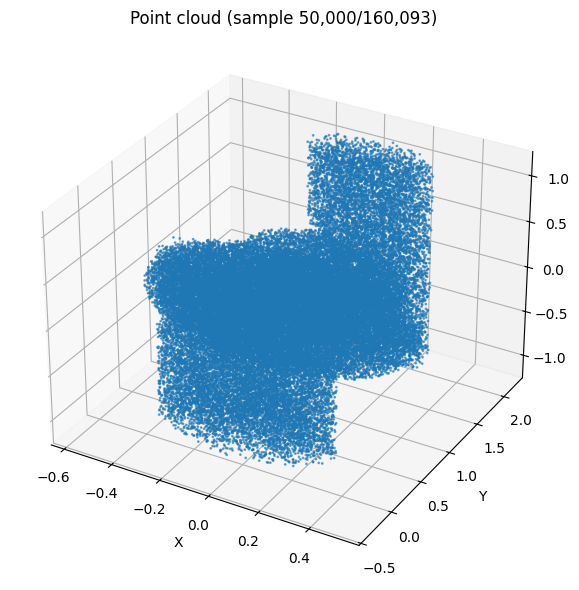

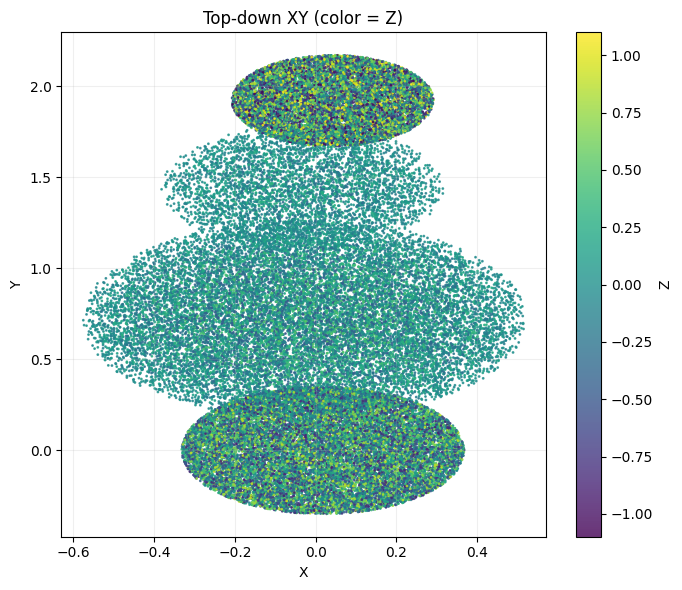

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

# df = point_cloud_to_dataframe(las_path, True)

# 1) uzmi koordinate iz df (podržava i x,y,z i X,Y,Z)
if all(c in df.columns for c in ["x","y","z"]):
    X, Y, Z = df["x"].to_numpy(), df["y"].to_numpy(), df["z"].to_numpy()
elif all(c in df.columns for c in ["X","Y","Z"]):
    X, Y, Z = df["X"].to_numpy(), df["Y"].to_numpy(), df["Z"].to_numpy()
else:
    raise ValueError(f"Ne nalazim x/y/z ili X/Y/Z u df: {list(df.columns)}")

pts = np.column_stack([X, Y, Z])
print("Point cloud details:", pts.shape)

# 2) Matplotlib 3D (po potrebi subsample radi brzine)
N = len(pts)
take = min(N, 50_000)
idx = np.random.choice(N, take, replace=False)
P = pts[idx]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(P[:,0], P[:,1], P[:,2], s=1, alpha=0.6)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.title(f"Point cloud (sample {take:,}/{N:,})")
plt.tight_layout()
plt.show()

# 3) (brzo i jako korisno) Top-down 2D
plt.figure(figsize=(7,6))
sc = plt.scatter(P[:,0], P[:,1], s=1, c=P[:,2], alpha=0.8)
plt.colorbar(sc, label="Z")
plt.xlabel("X"); plt.ylabel("Y")
plt.title("Top-down XY (color = Z)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 4) Open3D viewer (opcionalno)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
o3d.visualization.draw_geometries([pcd], window_name="LAS point cloud (Open3D)")


N points: 160093


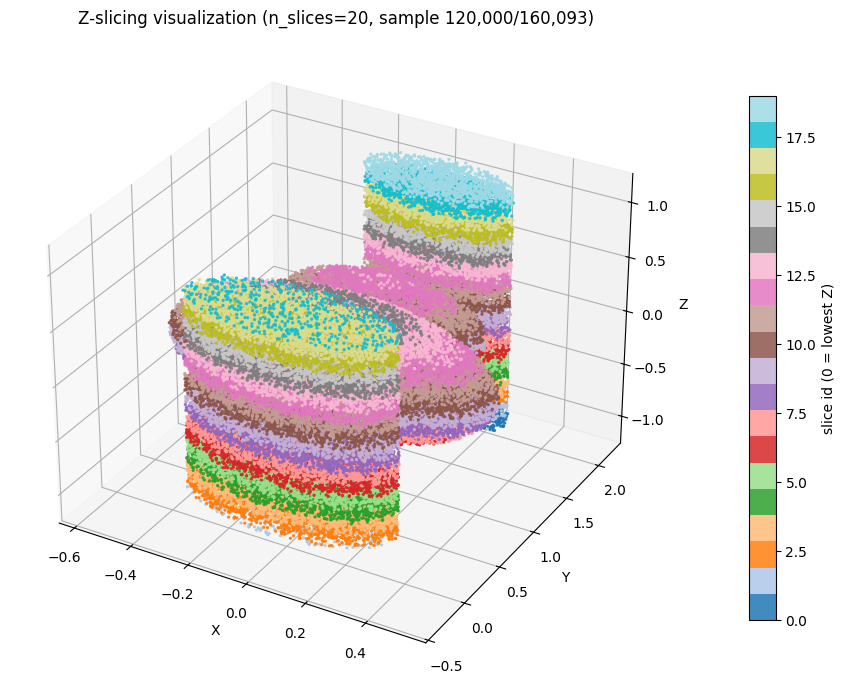

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- uzmi koordinate iz df ---
if all(c in df.columns for c in ["x","y","z"]):
    X = df["x"].to_numpy()
    Y = df["y"].to_numpy()
    Z = df["z"].to_numpy()
elif all(c in df.columns for c in ["X","Y","Z"]):
    X = df["X"].to_numpy()
    Y = df["Y"].to_numpy()
    Z = df["Z"].to_numpy()
else:
    raise ValueError(f"Ne nalazim x/y/z ili X/Y/Z u df: {list(df.columns)}")

pts = np.column_stack([X, Y, Z])
N = len(pts)
print("N points:", N)

# --- parametri ---
n_slices = 20              # promijeni po potrebi
max_plot_points = 120_000  # koliko tocaka crtamo (da bude brzo)

# --- slice indeks za svaku tocku ---
zmin, zmax = float(Z.min()), float(Z.max())
edges = np.linspace(zmin, zmax, n_slices + 1)

# digitize daje 1..n_slices, pa -1 -> 0..n_slices-1
slice_id = np.digitize(Z, edges, right=False) - 1
slice_id = np.clip(slice_id, 0, n_slices - 1)

# --- subsample za plot (ne mijenja izracun, samo prikaz) ---
take = min(N, max_plot_points)
idx = np.random.choice(N, take, replace=False)
P = pts[idx]
C = slice_id[idx]

# --- 3D plot: boja = slice_id ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(P[:,0], P[:,1], P[:,2],
                c=C, s=2, alpha=0.85, cmap="tab20")  # tab20 lijepo razlikuje 20 sliceva

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Z-slicing visualization (n_slices={n_slices}, sample {take:,}/{N:,})")

cb = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.8)
cb.set_label("slice id (0 = lowest Z)")

plt.tight_layout()
plt.show()


pts shape: (160093, 3)
Z range: -1.100 .. 1.100  |  dz≈0.0733 m
Counts: min/mean/max = 1109 5336 11271


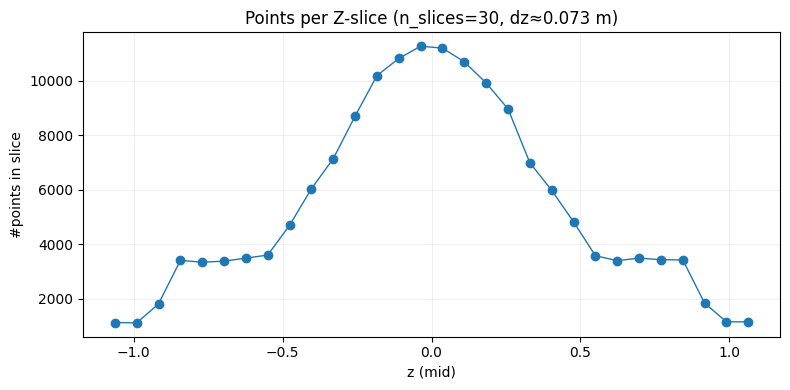

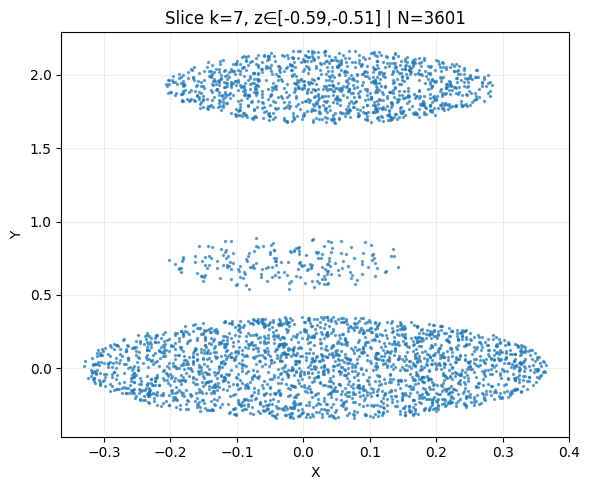

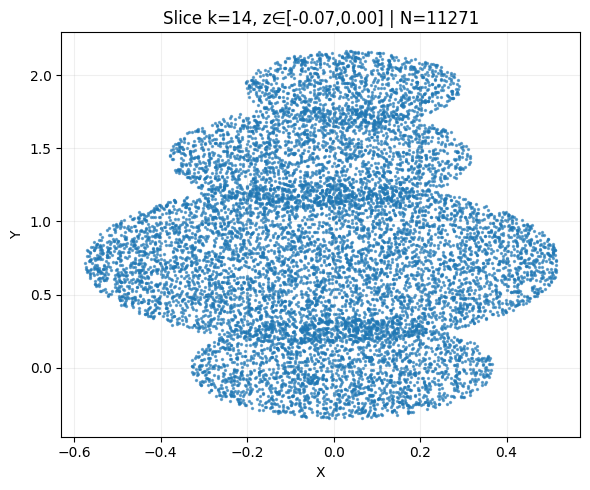

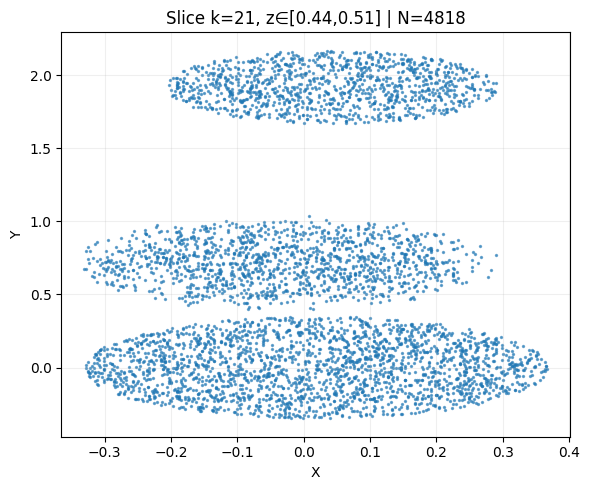

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- uzmi koordinate iz df ---
if all(c in df.columns for c in ["x","y","z"]):
    X = df["x"].to_numpy()
    Y = df["y"].to_numpy()
    Z = df["z"].to_numpy()
elif all(c in df.columns for c in ["X","Y","Z"]):
    X = df["X"].to_numpy()
    Y = df["Y"].to_numpy()
    Z = df["Z"].to_numpy()
else:
    raise ValueError(f"Ne nalazim x/y/z ili X/Y/Z u df: {list(df.columns)}")

pts = np.column_stack([X, Y, Z])
print("pts shape:", pts.shape)

# --- slicing funkcija (jednaka debljina po Z) ---
def slice_by_z(points, n_slices=30):
    zmin, zmax = float(points[:,2].min()), float(points[:,2].max())
    edges = np.linspace(zmin, zmax, n_slices + 1)
    slices = []
    mids = []
    dzs = []
    counts = []

    for k in range(n_slices):
        left, right = edges[k], edges[k+1]
        m = (points[:,2] >= left) & (points[:,2] < right if k < n_slices-1 else points[:,2] <= right)
        S = points[m]
        slices.append(S)
        mids.append(0.5*(left+right))
        dzs.append(right-left)
        counts.append(len(S))

    return slices, np.array(mids), np.array(dzs), np.array(counts), edges

# --- odaberi broj sliceva ---
n_slices = 30
slices, zmid, dz, counts, edges = slice_by_z(pts, n_slices=n_slices)

print(f"Z range: {edges[0]:.3f} .. {edges[-1]:.3f}  |  dz≈{dz.mean():.4f} m")
print("Counts: min/mean/max =", counts.min(), int(counts.mean()), counts.max())

# --- Viz 1: koliko točaka po sliceu (dijagnostika gustoće) ---
plt.figure(figsize=(8,4))
plt.plot(zmid, counts, marker="o", lw=1)
plt.xlabel("z (mid)")
plt.ylabel("#points in slice")
plt.title(f"Points per Z-slice (n_slices={n_slices}, dz≈{dz.mean():.3f} m)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- Viz 2: prikaži par sliceva u XY (presjek/otisak) ---
def plot_slice_xy(S, title):
    if len(S) == 0:
        print(title, "- prazno")
        return
    plt.figure(figsize=(6,5))
    plt.scatter(S[:,0], S[:,1], s=2, alpha=0.6)
    plt.xlabel("X"); plt.ylabel("Y")
    plt.title(title + f" | N={len(S)}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# uzmi: donji kvartil, srednji, gornji kvartil (po z)
k1 = int(0.25*(n_slices-1))
k2 = int(0.50*(n_slices-1))
k3 = int(0.75*(n_slices-1))

plot_slice_xy(slices[k1], f"Slice k={k1}, z∈[{edges[k1]:.2f},{edges[k1+1]:.2f}]")
plot_slice_xy(slices[k2], f"Slice k={k2}, z∈[{edges[k2]:.2f},{edges[k2+1]:.2f}]")
plot_slice_xy(slices[k3], f"Slice k={k3}, z∈[{edges[k3]:.2f},{edges[k3+1]:.2f}]")


NN dist [m]: median= 0.006082762530298225   p90= 0.011704699910719542   p95= 0.013928388277184133


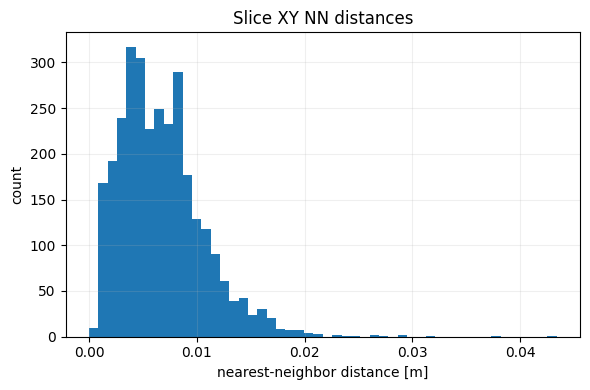

Suggested eps: 0.029261749776798854


In [6]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# XY iz slicea
XY = slices[k1][:, :2]
pcd2 = o3d.geometry.PointCloud()
pcd2.points = o3d.utility.Vector3dVector(np.c_[XY, np.zeros(len(XY))].astype(np.float64))

kdt = o3d.geometry.KDTreeFlann(pcd2)

# uzmi sample radi brzine
N = len(XY)
take = min(N, 3000)
idx = np.random.choice(N, take, replace=False)

dnn = []
for i in idx:
    _, _, d2 = kdt.search_knn_vector_3d(pcd2.points[i], 2)  # 1. je točka sama, 2. je najbliži susjed
    dnn.append(np.sqrt(d2[1]))
dnn = np.array(dnn)

print("NN dist [m]: median=", np.median(dnn), "  p90=", np.quantile(dnn, 0.9), "  p95=", np.quantile(dnn, 0.95))

plt.figure(figsize=(6,4))
plt.hist(dnn, bins=50)
plt.xlabel("nearest-neighbor distance [m]")
plt.ylabel("count")
plt.title("Slice XY NN distances")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# preporuka eps: npr. 2–3x p90
eps = 2.5 * np.quantile(dnn, 0.9)
print("Suggested eps:", eps)


Slice k=15, z∈[0.000,0.074]  |  N=11198

Cluster sizes in this slice:
  cluster   0: 11198 pts  (100.00%)
  noise  -1 :     0 pts  (  0.00%)
  total     : 11198 pts  (100.00%)
Clusters: 1 | Noise: 0/11198


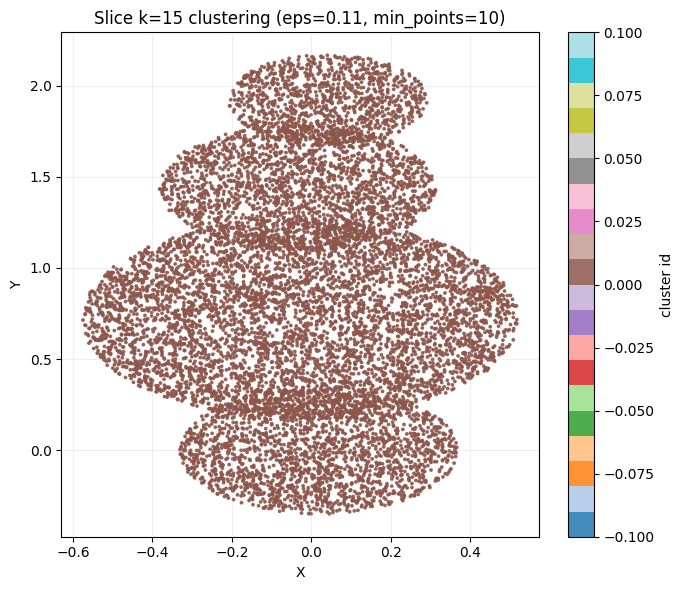

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

# Pretpostavka: vec imas
# slices = slice_by_z(pts, n_slices=...)
# edges = ...

k = len(slices) // 2
S = slices[k]
print(f"Slice k={k}, z∈[{edges[k]:.3f},{edges[k+1]:.3f}]  |  N={len(S)}")

# 2D XY za clustering
XY = S[:, :2]
pcd2 = o3d.geometry.PointCloud()
pcd2.points = o3d.utility.Vector3dVector(
    np.c_[XY, np.zeros(len(XY))].astype(np.float64)
)

# DBSCAN (Euclidean clustering)
eps = 0.11
min_points = 10   # spusteno s 20 (cesto je 20 pregrubo za rijedak slice)

labels = np.array(pcd2.cluster_dbscan(eps=eps, min_points=min_points, print_progress=False))

Nslice = len(labels)

# veličina svakog clustera (bez noise=-1)
valid = labels[labels >= 0]
if valid.size == 0:
    print("Nema klastera (sve noise).")
else:
    ids, counts = np.unique(valid, return_counts=True)

    # sort po veličini (najveći prvo)
    order = np.argsort(counts)[::-1]
    ids = ids[order]
    counts = counts[order]

    print("\nCluster sizes in this slice:")
    for cid, cnt in zip(ids, counts):
        print(f"  cluster {cid:>3}: {cnt:>5} pts  ({100*cnt/Nslice:6.2f}%)")

    noise = np.sum(labels == -1)
    print(f"  noise  -1 : {noise:>5} pts  ({100*noise/Nslice:6.2f}%)")
    print(f"  total     : {Nslice:>5} pts  (100.00%)")
n_clusters = int(labels.max() + 1)
n_noise = int(np.sum(labels == -1))
print(f"Clusters: {n_clusters} | Noise: {n_noise}/{len(labels)}")

# Vizualizacija u XY (boja=cluster id, noise=sivo)
plt.figure(figsize=(7,6))
noise = labels == -1
plt.scatter(XY[noise,0], XY[noise,1], s=2, alpha=0.15, label="noise (-1)")

mask = ~noise
sc = plt.scatter(XY[mask,0], XY[mask,1], s=3, c=labels[mask], alpha=0.85, cmap="tab20")
plt.colorbar(sc, label="cluster id")

plt.xlabel("X"); plt.ylabel("Y")
plt.title(f"Slice k={k} clustering (eps={eps}, min_points={min_points})")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.ops import polygonize

# --- 2D alpha/concave hull preko Delaunay (SciPy) ---
def alpha_hull_2d(points_xy: np.ndarray, Rmax: float):
    """
    points_xy: (N,2)
    Rmax: maksimalni circumradius triangla koji dopuštamo (u metrima)
    Returns: loops(list of (M,2) arrays), total_area
    """
    from scipy.spatial import Delaunay, ConvexHull

    P = np.asarray(points_xy, float)
    if len(P) < 4:
        return [], 0.0

    # Delaunay triangulacija
    tri = Delaunay(P)
    tris = tri.simplices

    # circumradius za svaki trokut
    A = P[tris[:,0]]
    B = P[tris[:,1]]
    C = P[tris[:,2]]

    a = np.linalg.norm(B - C, axis=1)
    b = np.linalg.norm(A - C, axis=1)
    c = np.linalg.norm(A - B, axis=1)

    s = 0.5*(a+b+c)
    area = np.sqrt(np.maximum(s*(s-a)*(s-b)*(s-c), 0.0))
    # R = abc / (4*Area)
    R = (a*b*c) / np.maximum(4.0*area, 1e-12)

    keep = R <= Rmax
    kept_tris = tris[keep]
    if len(kept_tris) == 0:
        # fallback: convex hull
        hull = ConvexHull(P)
        loop = P[hull.vertices]
        return [loop], polygon_area(loop)

    # Boundary edges: rubni bridovi su oni koji se pojave samo jednom
    edges = np.vstack([
        kept_tris[:,[0,1]],
        kept_tris[:,[1,2]],
        kept_tris[:,[2,0]],
    ])
    edges = np.sort(edges, axis=1)
    edges = np.ascontiguousarray(edges)

    # unique po redovima (svaki brid je red [i,j])
    uniq_edges, inv, cnt = np.unique(edges, axis=0, return_inverse=True, return_counts=True)

    # broj pojavljivanja za svaki originalni brid (duljine M)
    counts_per_edge = cnt[inv]          # shape (M,)
    boundary_mask = counts_per_edge == 1

    boundary_edges = edges[boundary_mask]  # shape (B,2)

    lines = [LineString([P[i], P[j]]) for i, j in boundary_edges]
    polys = list(polygonize(lines))  # vrati sve zatvorene poligone

    loops = [np.asarray(poly.exterior.coords)[:-1] for poly in polys]  # bez zadnje=prve
    total_area = float(sum(poly.area for poly in polys))

    # ako nije nasao nista, fallback convex hull
    if len(loops) == 0:
        hull = ConvexHull(P)
        loop = P[hull.vertices]
        return [loop], abs(polygon_area(loop))

    return loops, total_area

    # adjacency
    adj = {}
    for i,j in boundary_edges:
        adj.setdefault(i, []).append(j)
        adj.setdefault(j, []).append(i)

    # izgradi petlje (loops) od rubnih bridova
    used = set()
    loops = []

    def edge_key(i,j):
        return (i,j) if i<j else (j,i)

    for i,j in boundary_edges:
        ek = edge_key(i,j)
        if ek in used:
            continue

        # start walking
        loop = [i, j]
        used.add(ek)
        prev = i
        cur = j

        while True:
            nbrs = adj.get(cur, [])
            if len(nbrs) == 0:
                break
            # odaberi sljedeceg susjeda koji nije prev, a edge nije used
            nxt = None
            for cand in nbrs:
                if cand == prev:
                    continue
                ek2 = edge_key(cur, cand)
                if ek2 not in used:
                    nxt = cand
                    break
            if nxt is None:
                # mozda se zatvara petlja na početak
                if loop[-1] == loop[0]:
                    break
                # probaj zatvoriti ako postoji brid do starta
                if loop[0] in nbrs and edge_key(cur, loop[0]) not in used:
                    nxt = loop[0]
                else:
                    break

            used.add(edge_key(cur, nxt))
            loop.append(nxt)
            prev, cur = cur, nxt

            if cur == loop[0]:
                break

        # valid loop mora imati barem 4 indexa (3 vrha + povratak)
        if len(loop) >= 4 and loop[-1] == loop[0]:
            coords = P[np.array(loop[:-1])]
            loops.append(coords)

    # area = zbroj area svih petlji
    total_area = sum(abs(polygon_area(L)) for L in loops)
    return loops, total_area


def polygon_area(loop_xy: np.ndarray) -> float:
    """Shoelace area for ordered polygon vertices."""
    x = loop_xy[:,0]
    y = loop_xy[:,1]
    return 0.5 * np.sum(x*np.roll(y,-1) - y*np.roll(x,-1))



cluster   0: N=11198, area≈1.954 m^2, loops=1

Slice area Ak (sum of kept clusters) ≈ 1.954 m^2  | kept_clusters=1


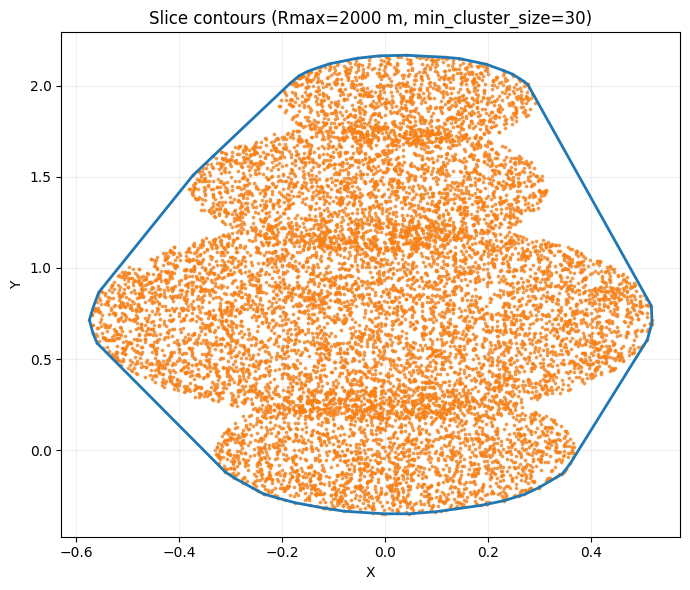

In [9]:

# -----------------------------
# 1) Parametri
min_cluster_size = 30   # ignoriraj sitne klastere (šum)
Rmax = 2000     # "concavity" parametar (m) -> probaj 0.15–0.50

# 2) Izračun area po klasteru + vizualizacija
plt.figure(figsize=(7,6))
plt.scatter(XY[:,0], XY[:,1], s=2, alpha=0.15, label="all slice pts")

Ak = 0.0
kept = 0

for cid in sorted(set(labels)):
    if cid == -1:
        continue
    mask = labels == cid
    Pcid = XY[mask]
    if len(Pcid) < min_cluster_size:
        continue

    loops, area = alpha_hull_2d(Pcid, Rmax=Rmax)
    Ak += area
    kept += 1

    # plot points
    plt.scatter(Pcid[:,0], Pcid[:,1], s=3, alpha=0.6)

    # plot contour(s)
    for L in loops:
        plt.plot(np.r_[L[:,0], L[0,0]], np.r_[L[:,1], L[0,1]], lw=2)

    print(f"cluster {cid:>3}: N={len(Pcid):>4}, area≈{area:.3f} m^2, loops={len(loops)}")

print(f"\nSlice area Ak (sum of kept clusters) ≈ {Ak:.3f} m^2  | kept_clusters={kept}")
plt.title(f"Slice contours (Rmax={Rmax} m, min_cluster_size={min_cluster_size})")
plt.xlabel("X"); plt.ylabel("Y")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [10]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# Parametri (start)
min_points = 10
min_cluster_size = 30

# eps uzmi iz svog NN histograma (ili ostavi ručno)
# eps = 2.5 * p90
# primjer:
# eps = 0.11

# Rmax mora biti u metrima, NE 2000
# primjer:
# Rmax = 0.30

A = np.zeros(len(slices), dtype=float)       # area po sliceu
keptC = np.zeros(len(slices), dtype=int)     # koliko klastera zadržano
noiseFrac = np.zeros(len(slices), dtype=float)

for k, S in enumerate(slices):
    if len(S) < min_points:
        A[k] = 0.0
        keptC[k] = 0
        noiseFrac[k] = 1.0
        continue

    XY = S[:, :2].astype(np.float64)

    # DBSCAN na XY (Open3D)
    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(np.c_[XY, np.zeros(len(XY))])
    labels = np.array(pcd2.cluster_dbscan(eps=eps, min_points=min_points, print_progress=False))

    noise = np.sum(labels == -1)
    noiseFrac[k] = noise / len(labels)

    Ak = 0.0
    kept = 0

    for cid in sorted(set(labels)):
        if cid == -1:
            continue
        Pcid = XY[labels == cid]
        if len(Pcid) < min_cluster_size:
            continue

        loops, area = alpha_hull_2d(Pcid, Rmax=Rmax)
        Ak += float(area)
        kept += 1

    A[k] = Ak
    keptC[k] = kept

# Volumen: suma A_k * dz_k
V = float(np.sum(A * dz))
print("Estimated volume [m^3]:", V)


Estimated volume [m^3]: 2.228042410000001


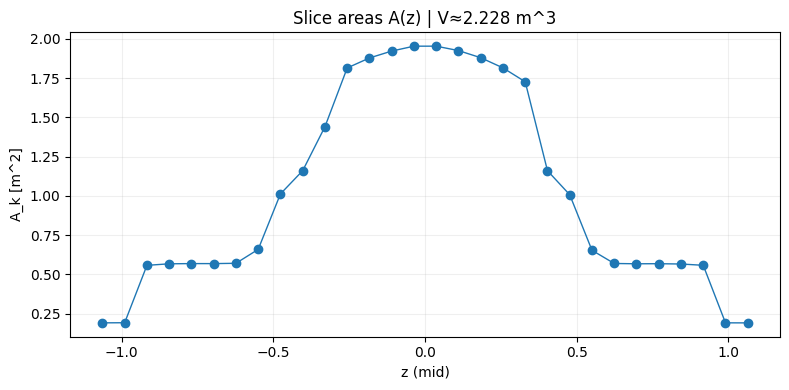

In [11]:
plt.figure(figsize=(8,4))
plt.plot(zmid, A, marker="o", lw=1)
plt.xlabel("z (mid)")
plt.ylabel("A_k [m^2]")
plt.title(f"Slice areas A(z) | V≈{V:.3f} m^3")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


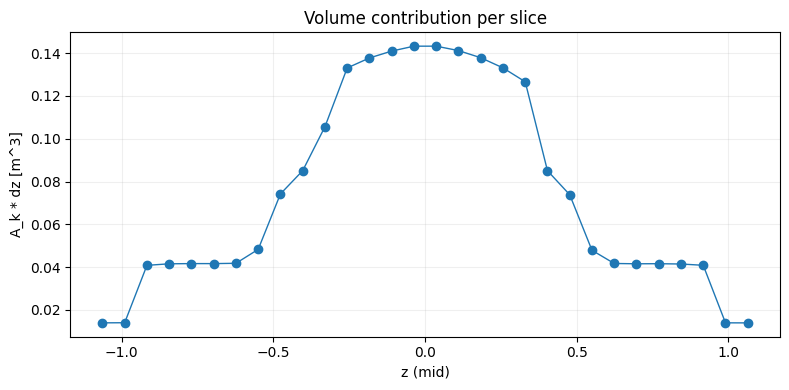

In [12]:
plt.figure(figsize=(8,4))
plt.plot(zmid, A*dz, marker="o", lw=1)
plt.xlabel("z (mid)")
plt.ylabel("A_k * dz [m^3]")
plt.title("Volume contribution per slice")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


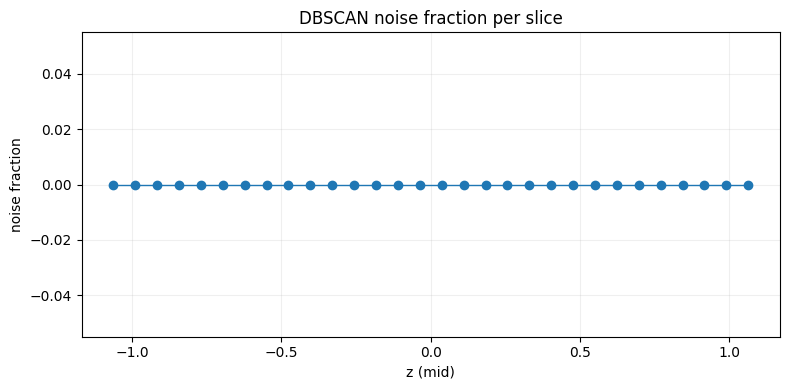

In [13]:
plt.figure(figsize=(8,4))
plt.plot(zmid, noiseFrac, marker="o", lw=1)
plt.xlabel("z (mid)")
plt.ylabel("noise fraction")
plt.title("DBSCAN noise fraction per slice")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
